# XGBoost + SHAP Analysis - ADHD

**Author:** Ria Martins

**Description:** County-level ADHD prevalence modeled using XGBoost with Recursive Feature Elimination (RFE) and SHAP-based interpretation.

**Pipeline:**
1. Load and prepare data
2. Hyperparameter tuning (RandomizedSearchCV, 5-fold)
3. RFE down to 12 features
4. 5-fold CV evaluation
5. Final model fit + SHAP values
6. Plots: bar, beeswarm, PDP, dependence
7. County-level top SHAP drivers

**Notes:**
- Feature selection is not nested within CV
- SHAP reflects in-sample explanations


In [ ]:
# 1. Imports
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# Set global font

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "figure.dpi": 300
})

In [ ]:
# 2. Load and prepare data

DATA_PATH = "/content/ADHD + Environment.csv"

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

# Outcome
y = df["ADHD_PREV_MEAN"].astype(float)

# Features: drop target and county identifier
X = df.drop(columns=["ADHD_PREV_MEAN", "FIPS"])

# Ensure numeric + simple median imputation
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Clean column names so XGBoost is happy
X.columns = (
    X.columns
    .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
    .str.strip("_")
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3143, 140)
y shape: (3143,)


In [ ]:
# 3. Hyperparameter tuning (RandomizedSearchCV)

cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    "n_estimators":     [300, 500, 700, 900],
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":        [0.5, 0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma":            [0, 1, 2, 3, 5],
    "reg_alpha":        [0, 0.1, 0.5, 1.0],
    "reg_lambda":       [1, 3, 5, 10],
}

base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y)
best_model = search.best_estimator_
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}


In [ ]:
# 4. Recursive Feature Elimination (RFE) → 12 features

def rfe_xgb(model, X, y, target_n=12, drop_frac=0.10):
    """Iteratively drop the lowest-importance features until target_n remain."""
    features = list(X.columns)

    while len(features) > target_n:
        model.fit(X[features], y)

        importances = pd.Series(
            model.feature_importances_, index=features
        ).sort_values()

        drop_n = max(1, int(len(features) * drop_frac))
        drop_feats = importances.index[:drop_n].tolist()
        features = [f for f in features if f not in drop_feats]

    return features


selected_12 = rfe_xgb(best_model, X, y, target_n=12, drop_frac=0.10)
print("Selected 12 features:")
for f in selected_12:
    print(" -", f)

Selected 12 features:
 - Carbon_Monoxide
 - Benzidine
 - Social_service_agencies
 - Radon_zone
 - Families_in_poverty
 - Median_household_income
 - Income_inequality
 - Calcium_precipitation
 - Nitrate_precipitation
 - Sulfate_precipitation
 - Mercury_deposition
 - Antimony


In [ ]:
# 5. 5-fold CV evaluation on selected features

rmse_scores = -cross_val_score(
    best_model, X[selected_12], y,
    scoring="neg_root_mean_squared_error", cv=cv5, n_jobs=-1,
)

r2_scores = cross_val_score(
    best_model, X[selected_12], y,
    scoring="r2", cv=cv5, n_jobs=-1,
)

print(f"5-fold CV RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"5-fold CV R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

5-fold CV RMSE: 2.6856 ± 0.0639
5-fold CV R²:   0.4682 ± 0.0284


In [ ]:
# 6. Fit final model on full data (for SHAP and PDP)

final_model = XGBRegressor(
    **search.best_params_,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
final_model.fit(X[selected_12], y)
print("Final model fitted on", X[selected_12].shape)

Final model fitted on (3143, 12)


In [ ]:
# 7. SHAP values + ranking

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X[selected_12])

# Rank features by mean |SHAP|
shap_importance = pd.DataFrame({
    "feature": selected_12,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(shap_importance)

                    feature  mean_abs_shap
0        Mercury_deposition       0.973039
1     Nitrate_precipitation       0.596176
2   Social_service_agencies       0.470856
3     Calcium_precipitation       0.426358
4     Sulfate_precipitation       0.361361
5           Carbon_Monoxide       0.304731
6         Income_inequality       0.288740
7                 Benzidine       0.268860
8   Median_household_income       0.266630
9                Radon_zone       0.253880
10      Families_in_poverty       0.252146
11                 Antimony       0.134373


In [ ]:
# 8. SHAP bar and beeswarm plots

# Display version of feature names
X_display = X[selected_12].copy()
X_display.columns = [c.replace("_", " ") for c in X_display.columns]

# A) Bar plot
plt.figure()
shap.summary_plot(shap_values, X_display, plot_type="bar", show=False)
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.title("A) Feature Importance Plot", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("shap_bar.tiff", dpi=600, bbox_inches="tight")
plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")
plt.close()

# B) Beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_display, show=False)
plt.title("B) Beeswarm Plot", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.tiff", dpi=600, bbox_inches="tight")
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.close()

# C) Combine into one row
bar = Image.open("shap_bar.tiff")
bee = Image.open("shap_beeswarm.tiff")

target_h = max(bar.height, bee.height)
bar = bar.resize((int(bar.width * target_h / bar.height), target_h), Image.Resampling.LANCZOS)
bee = bee.resize((int(bee.width * target_h / bee.height), target_h), Image.Resampling.LANCZOS)

combined = Image.new("RGB", (bar.width + bee.width, target_h), (255, 255, 255))
combined.paste(bar, (0, 0))
combined.paste(bee, (bar.width, 0))

combined.save("SHAP_bar_beeswarm_row.png",  dpi=(600, 600))
combined.save("SHAP_bar_beeswarm_row.tiff", dpi=(600, 600))

print("Saved SHAP bar, beeswarm, and combined row plots.")

/tmp/ipykernel_5408/2039417453.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_display, plot_type="bar", show=False)
/tmp/ipykernel_5408/2039417453.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_display, show=False)


Saved SHAP bar, beeswarm, and combined row plots.


In [ ]:
# 9. Partial dependence plots for top-K SHAP variables

K = 6
top_vars = shap_importance["feature"].head(K).tolist()
pretty_names = {v: v.replace("_", " ").title() for v in top_vars}

print(f"Making PDP plots for top {K} variables:")
print(top_vars)

for v in top_vars:
    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X[selected_12],
        features=[v],
        kind="average",
        grid_resolution=60,
        percentiles=(0.01, 0.99),
        ax=ax,
    )

    ax.set_title(f"PDP: {pretty_names[v]}")
    ax.set_xlabel(pretty_names[v])

    plt.tight_layout()
    plt.savefig(f"pdp_{v}.png", dpi=300, bbox_inches="tight")
    plt.close()

print("PDP plots saved.")

Making PDP plots for top 6 variables:
['Mercury_deposition', 'Nitrate_precipitation', 'Social_service_agencies', 'Calcium_precipitation', 'Sulfate_precipitation', 'Carbon_Monoxide']


PDP plots saved.


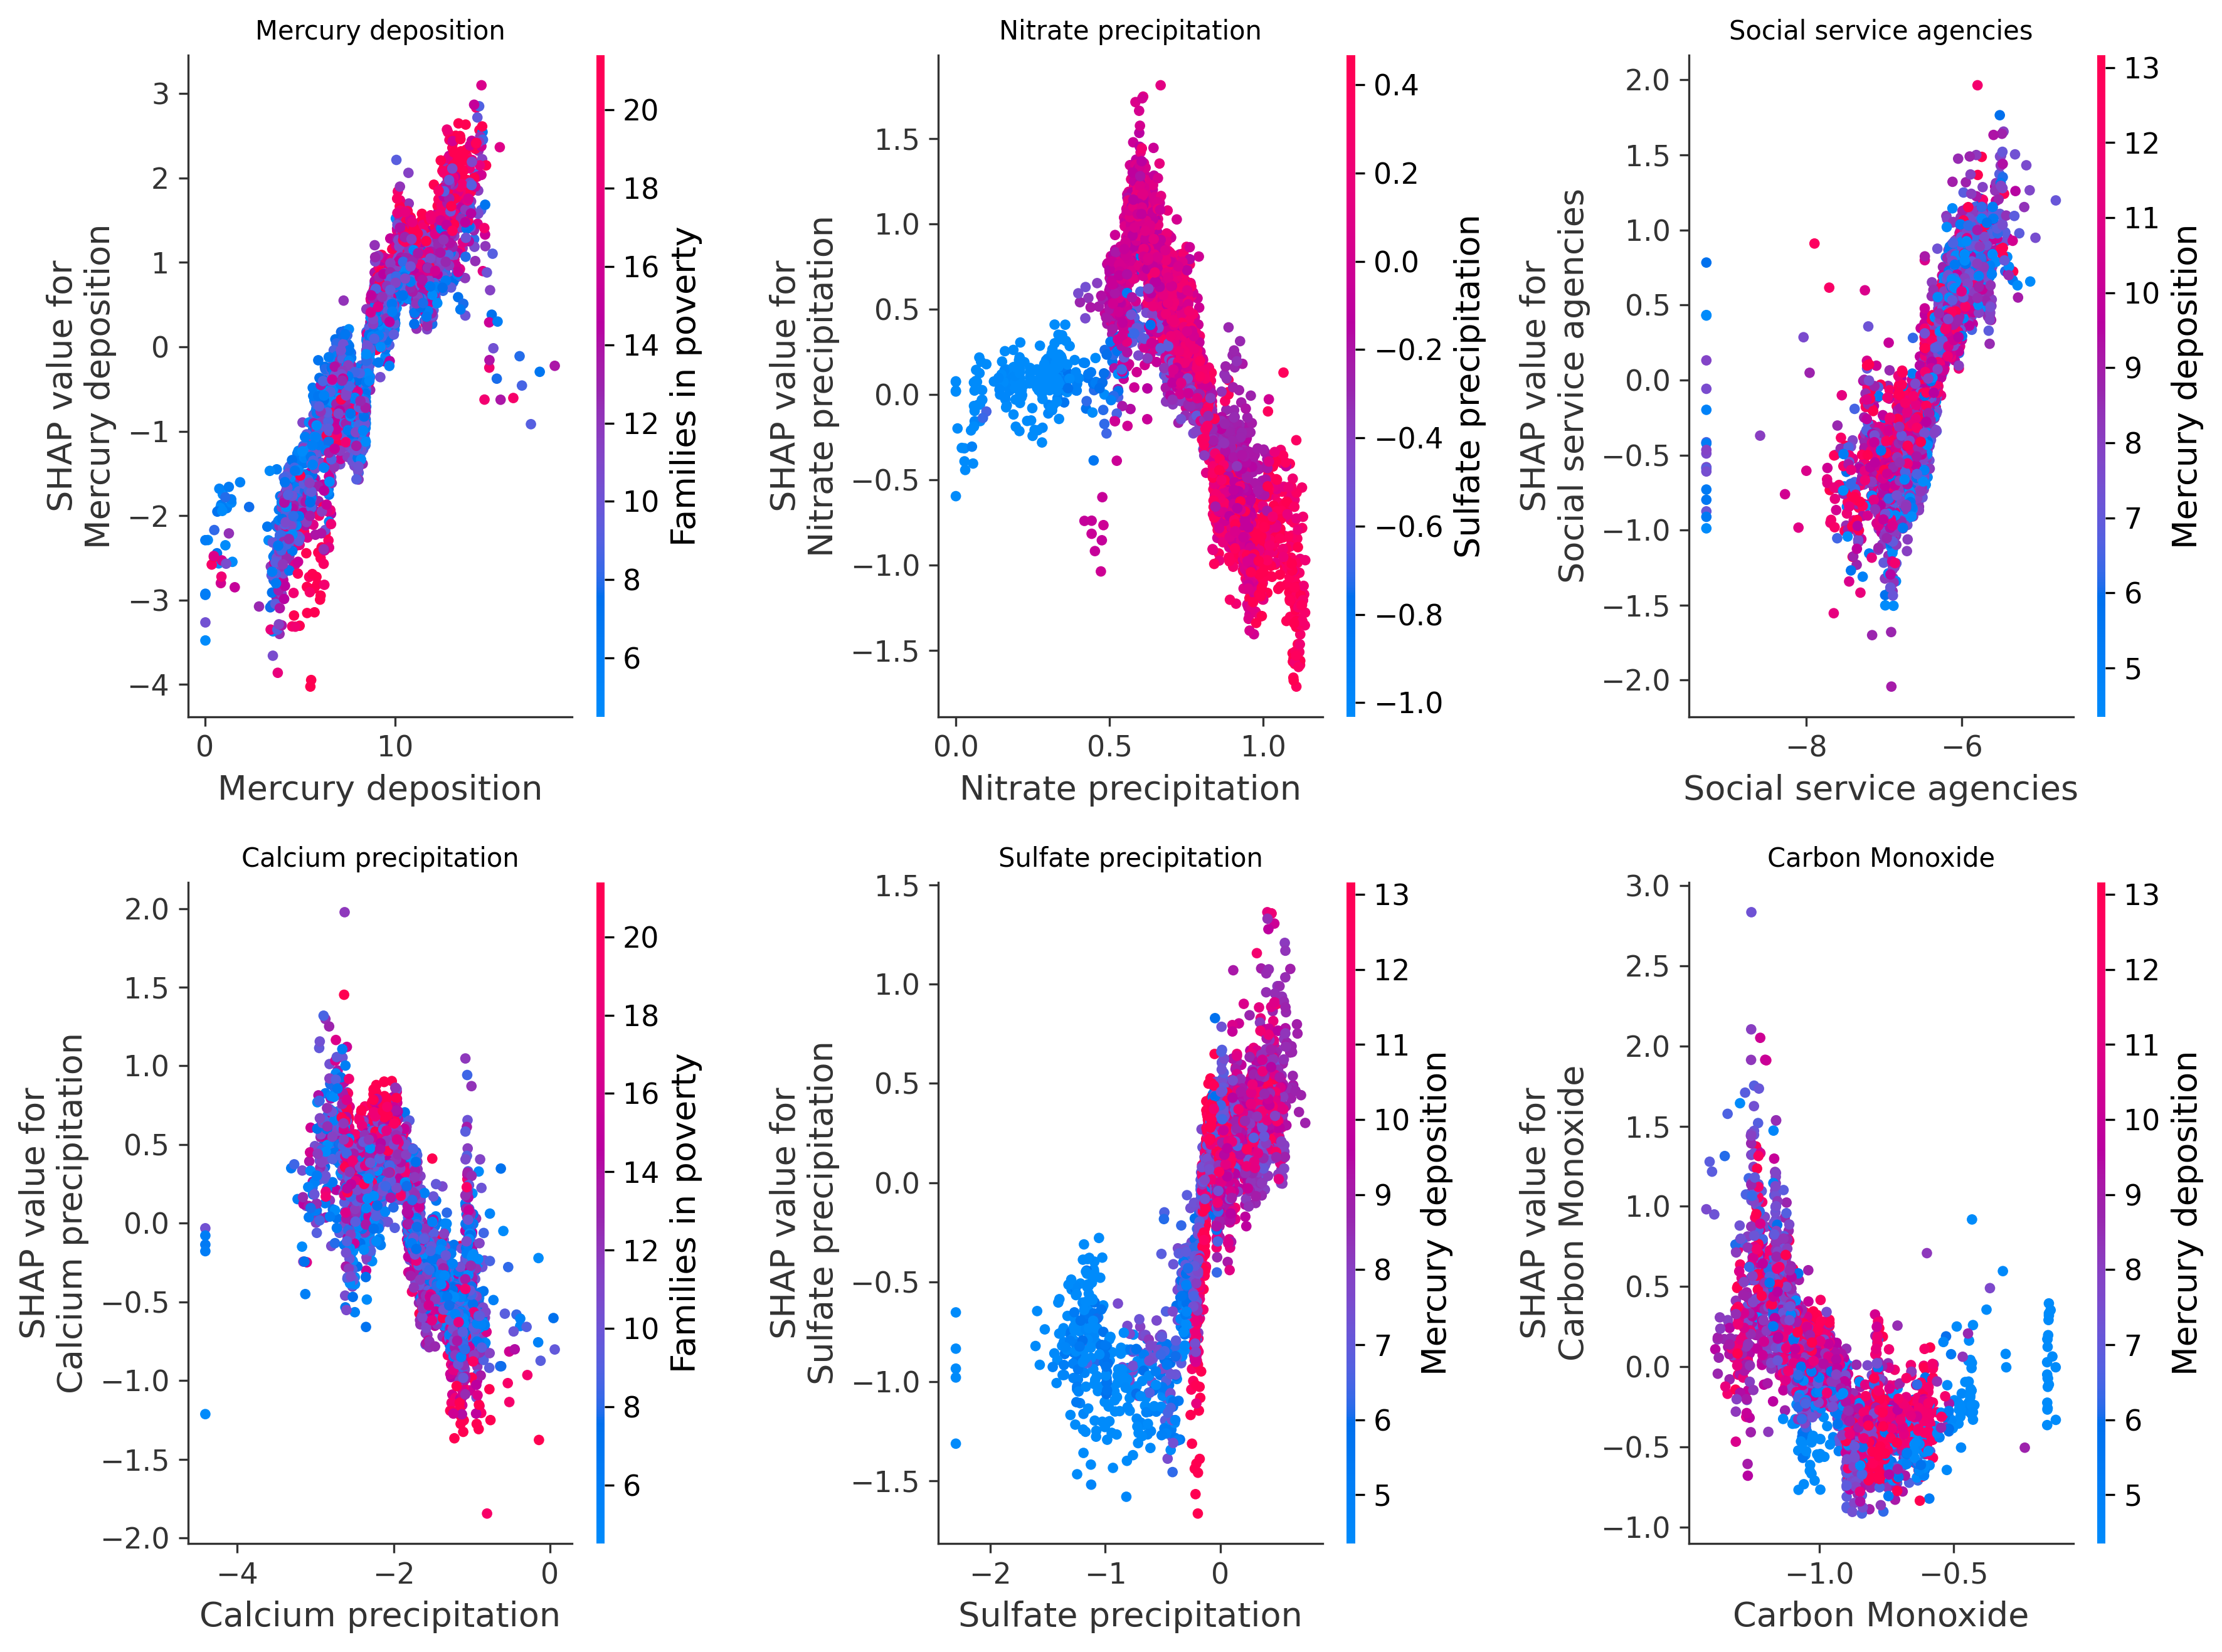

In [ ]:
# 10. SHAP dependence plots (top 6 panel)

X_selected_display = X[selected_12].copy()
X_selected_display.columns = [c.replace("_", " ") for c in X_selected_display.columns]

top_vars_clean = [v.replace("_", " ") for v in top_vars]

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
axes = axes.ravel()

for i, v_clean in enumerate(top_vars_clean):
    if i >= len(axes):
        break
    plt.sca(axes[i])
    shap.dependence_plot(
        ind=v_clean,
        shap_values=shap_values,
        features=X_selected_display,
        interaction_index="auto",
        show=False,
        ax=axes[i],
    )
    axes[i].set_title(v_clean, fontsize=10)
    axes[i].set_xlabel(v_clean)

# Hide any unused axes
for j in range(len(top_vars_clean), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("shap_dependence_top6_panel.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [20]:
# 11. County-level top SHAP driver

shap_df = pd.DataFrame(shap_values, columns=selected_12)
shap_df["FIPS"] = df["FIPS"].values

# Top driver per county = feature with largest |SHAP|
shap_df["Top_Driver"] = shap_df[selected_12].abs().idxmax(axis=1)

# Clean names for output
shap_df["Top_Driver"] = shap_df["Top_Driver"].str.replace("_", " ", regex=False)

shap_df[["FIPS", "Top_Driver"]].to_csv("county_top_drivers.csv", index=False)

print(shap_df[["FIPS", "Top_Driver"]].head())
print("\nSaved: county_top_drivers.csv")

   FIPS             Top_Driver
0  1001  Nitrate precipitation
1  1003     Mercury deposition
2  1005     Mercury deposition
3  1007     Mercury deposition
4  1009  Nitrate precipitation

Saved: county_top_drivers.csv
